In [1]:
# MOVIE-SENTIBOT: Model 4 - Random Forest Classifier

# ### Step 1: Import Necessary Libraries
print("Step 1: Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import time # To time the training process

# Set plot style for better visualizations
sns.set_style('whitegrid')
print("Libraries imported successfully.\n")

Step 1: Importing libraries...
Libraries imported successfully.



In [2]:
# ### Step 2: Mount Google Drive and Load Preprocessed Data
# We connect to Google Drive to use the same preprocessed dataset.
print("Step 2: Loading preprocessed data from Google Drive...")

try:
    # Mount Google Drive if not already mounted
    if not os.path.isdir('/content/drive/My Drive'):
        drive.mount('/content/drive')

    # --- Use the exact path to your preprocessed data ---
    file_path = '/content/drive/MyDrive/AIML assignment/results/preprocessed_reviews.csv'

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file was not found at '{file_path}'. Please double-check the path.")

    df = pd.read_csv(file_path)

    print("Preprocessed dataset loaded successfully.")
    print("\nDataset Head:")
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")

Step 2: Loading preprocessed data from Google Drive...
Mounted at /content/drive
Preprocessed dataset loaded successfully.

Dataset Head:
                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time money visual stun film...          1


In [3]:
# ### Step 3: Feature Extraction (TF-IDF Vectorization)
print("\nStep 3: Performing TF-IDF Vectorization...")

df['review'].fillna('', inplace=True)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

print(f"Shape of the TF-IDF feature matrix: {X.shape}")


Step 3: Performing TF-IDF Vectorization...


/tmp/ipython-input-770124444.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna('', inplace=True)


Shape of the TF-IDF feature matrix: (50000, 5000)


In [4]:
# ### Step 4: Split Data into Training and Testing Sets
print("\nStep 4: Splitting data into training (80%) and testing (20%) sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Step 4: Splitting data into training (80%) and testing (20%) sets...
Training set size: 40000 samples
Testing set size: 10000 samples


In [5]:
# Step 5: Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

print("Step 5: Performing hyperparameter tuning with GridSearchCV...")

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters
print(f"Best parameters found: {grid_search.best_params_}")

# Get the best model
model = grid_search.best_estimator_

print("Hyperparameter tuning complete.")

Step 5: Performing hyperparameter tuning with GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters found: {'max_depth': None, 'n_estimators': 200}
Hyperparameter tuning complete.



Step 6: Evaluating the model...

Model Accuracy: 0.8595 (85.95%)

Classification Report:
              precision  recall  f1-score     support
Negative       0.858139  0.8614  0.859766   5000.0000
Positive       0.860871  0.8576  0.859233   5000.0000
accuracy       0.859500  0.8595  0.859500      0.8595
macro avg      0.859505  0.8595  0.859499  10000.0000
weighted avg   0.859505  0.8595  0.859499  10000.0000
Confusion Matrix:


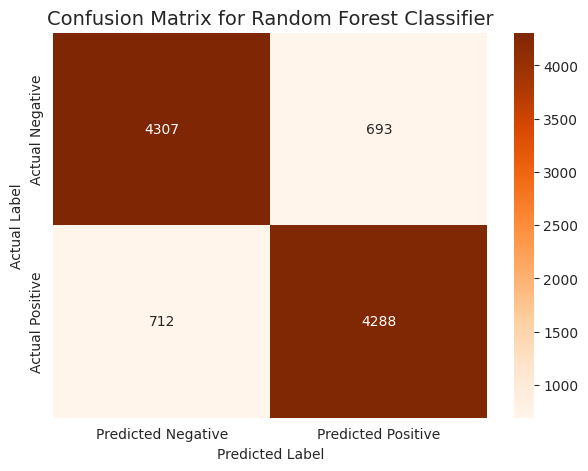

In [6]:
# ### Step 6: Evaluate the Model's Performance
print("\nStep 6: Evaluating the model...")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f} ({accuracy:.2%})")

print("\nClassification Report:")
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Random Forest Classifier', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [7]:
# Step 7: Save the results
print("Step 7: Saving the results...")

# Define the directory to save the results
results_dir = '/content/drive/MyDrive/AIML assignment/results/random_forest_IT24100068'
os.makedirs(results_dir, exist_ok=True)

# Save the classification report to a CSV file
report_df.to_csv(os.path.join(results_dir, 'classification_report.csv'))

# Save the confusion matrix plot
cm_plot_path = os.path.join(results_dir, 'confusion_matrix.png')
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Random Forest Classifier', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(cm_plot_path)
plt.close()

# Save the accuracy to a text file
accuracy_path = os.path.join(results_dir, 'accuracy.txt')
with open(accuracy_path, 'w') as f:
    f.write(f'Model Accuracy: {accuracy:.4f} ({accuracy:.2%})')

print(f"Results saved to {results_dir}")

Step 7: Saving the results...
Results saved to /content/drive/MyDrive/AIML assignment/results/random_forest_IT24100068
